# Step 1: Data Overview

### Environment and Dataset Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

In [ ]:
# Connecting Google Drive
from google.colab import drive
drive.mount("/content/drive")

# Changing work folder
%cd /content/drive/MyDrive/Mate/python_da/module_task

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Mate/python_da/module_task


### 1.1. Countries Table Overview:

In [ ]:
# Checking Countries table
countries = pd.read_csv('countries.csv')
countries.info()
print()
countries.head(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        249 non-null    object
 1   alpha-2     248 non-null    object
 2   alpha-3     249 non-null    object
 3   region      248 non-null    object
 4   sub-region  248 non-null    object
dtypes: object(5)
memory usage: 9.9+ KB



,name,alpha-2,alpha-3,region,sub-region
0,Afghanistan,AF,AFG,Asia,Southern Asia
1,Åland Islands,AX,ALA,Europe,Northern Europe


**Columns:**
- `name` - country name.
- `alpha-2` - 2-symbols country code.
- `alpha-3` - 3-symbols country code.
- `region` - in which region country is located.
- `sub-region` - in which sub-region country is located.

### 1.2. Events Table Overview

In [ ]:
# Checking Events table
events = pd.read_csv('events.csv')
events.info()
print()
events.head(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1330 non-null   int64  
 1   Order Date      1330 non-null   object 
 2   Ship Date       1330 non-null   object 
 3   Order Priority  1330 non-null   object 
 4   Country Code    1248 non-null   object 
 5   Product ID      1330 non-null   int64  
 6   Sales Channel   1330 non-null   object 
 7   Units Sold      1328 non-null   float64
 8   Unit Price      1330 non-null   float64
 9   Unit Cost       1330 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 104.0+ KB



,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.7,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.7,117.11


In [ ]:
events.describe()

,Order ID,Product ID,Units Sold,Unit Price,Unit Cost
count,1.330000e+03,1330.000000,1328.000000,1330.000000,1330.000000
mean,5.412048e+08,5788.096241,4952.201807,264.893541,187.246812
std,2.573882e+08,2820.728878,2905.198996,217.323460,176.158873
min,1.006406e+08,1270.000000,2.000000,9.330000,6.920000
25%,3.190004e+08,3127.000000,2356.750000,81.730000,35.840000
50%,5.387164e+08,5988.000000,4962.000000,154.060000,97.440000
75%,7.544628e+08,8681.000000,7459.500000,437.200000,263.330000
max,9.998797e+08,8969.000000,9999.000000,668.270000,524.960000


**Columns**:
- `Order ID` - order id, it's better to convert to string.
- `Order Date` - date when order was made, it's better to convert to datetime.
- `Ship Date` - date when order was shipped to the customer, it's better to convert to datetime.
- `Order Priority` - order priority for the company.
- `Country Code `- country to which company should ship the order.
- `Product ID` - code of the product.
- `Sales Channel` - by which channel the product was made.
- `Units Sold` - how many product units were purchased in the order.
- `Unit Price` - price per unit.
- `Unit Cost` - how much it costs for the company to produce/buy from supplier the product.

### 1.3. Products Table Overview

In [ ]:
# Checking Products table
products = pd.read_csv('products.csv')
products.info()
print()
products.head(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         12 non-null     int64 
 1   item_type  12 non-null     object
dtypes: int64(1), object(1)
memory usage: 324.0+ bytes



,id,item_type
0,2103,Cereal
1,7940,Household
2,2455,Clothes
3,1270,Beverages
4,8681,Office Supplies


**Columns**:
- `id` - product id, it's better to convert to string.
- `item_type` - product name.

In [ ]:
# Updating Countries column names for easier addressing them
countries.columns = countries.columns.str.lower().str.replace("-", "_")
print(f"{countries.columns}\n")

# Updating Events column names for easier addressing them
events.columns = events.columns.str.lower().str.replace(" ", "_")
print(f"{events.columns}\n")

# No need in updating products' colunms as they already match snake_case style

Index(['name', 'alpha_2', 'alpha_3', 'region', 'sub_region'], dtype='object')

Index(['order_id', 'order_date', 'ship_date', 'order_priority', 'country_code',
       'product_id', 'sales_channel', 'units_sold', 'unit_price', 'unit_cost'],
      dtype='object')



### Tables connection with each other:
The main table will be Events as it contains most data in it.
We'll do LEFT JOINS to add data about countries and product names:
- `[events].country_code = [countries].alpha_3` - as country code contains 3 symbols only, it is similar to the alpha_3 column in the Countries table.
- `[events].product_id = [products].id` - product id from events table matches the id column in the Products table.

# Step 2: Data cleaning

### 2.1. Data cleaning - Countries Table

In [ ]:
# Checking if we have NaN values in the table
print(countries.isna().sum())

name          0
alpha_2       1
alpha_3       0
region        1
sub_region    1
dtype: int64


As we see, there is 1 NaN value in alpha_2, region, and sub-region columns.

In [ ]:
#We should check and review if we can assign data to NA values (based on our knowledge)
na_countries = countries[(countries["alpha_2"].isna()) | (countries["region"].isna()) | (countries["sub_region"].isna())]
na_countries

,name,alpha_2,alpha_3,region,sub_region
8,Antarctica,AQ,ATA,NaN,NaN
153,Namibia,NaN,NAM,Africa,Sub-Saharan Africa


In [ ]:
# We got NaN for Namibia because its 2-symbol code is NA (first 2 symbols)
# Since we know the country, we should correct the value not to miss it in the list.

countries.loc[countries['name'] == 'Namibia', 'alpha_2'] = 'NA'

# Checking if Namibia's error was fixed
na_countries = countries[(countries["alpha_2"].isna()) | (countries["region"].isna()) | (countries["sub_region"].isna())]
na_countries

,name,alpha_2,alpha_3,region,sub_region
8,Antarctica,AQ,ATA,NaN,NaN


In [ ]:
# Fixing Antarctica's values:
countries.loc[countries['name'] == 'Antarctica', ['region', 'sub_region']] = 'Antarctica'

# Checking if Antarctica's error was fixed:
na_countries = countries[(countries["alpha_2"].isna()) | (countries["region"].isna()) | (countries["sub_region"].isna())]
na_countries

,name,alpha_2,alpha_3,region,sub_region


In [ ]:
# Standardizing string (object) columns
countries["name"] = countries["name"].str.strip().str.title()
countries["alpha_2"] = countries["alpha_2"].str.strip().str.upper()
countries["alpha_3"] = countries["alpha_3"].str.strip().str.upper()
countries["region"] = countries["region"].str.strip().str.title()
countries["sub_region"] = countries["sub_region"].str.strip().str.title()

In [ ]:
# List of cyryllic and latin letters that look the same
similar_letters = {
    'а': 'a', 'с': 'c', 'е': 'e', 'і': 'i', 'о': 'o', 'р': 'p', 'х': 'x', 'у': 'y', 'і': 'i',
    'А': 'A', 'В': 'B', 'Е': 'E', 'І': 'I', 'К': 'K', 'М': 'M', 'Н': 'H', 'О': 'O', 'Р': 'P', 'С': 'C', 'Т': 'T', 'Х': 'X'
}

In [ ]:
# Checking if AI brought me correct letters dict
for key, value in similar_letters.items():
    if ord(key) == ord(value):
      print({key})

In [ ]:
# Combining all str (object) columns
str_columns = countries.select_dtypes(include=['object']).columns

# Replacing all cyryllic to latin letters
countries[str_columns] = countries[str_columns].replace(similar_letters, regex=True)

In [ ]:
# Checking for duplicated values
countries_duplicated = countries.duplicated()
countries_duplicated.sum()

np.int64(0)

In [ ]:
# Final check if our changes were applied
countries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        249 non-null    object
 1   alpha_2     249 non-null    object
 2   alpha_3     249 non-null    object
 3   region      249 non-null    object
 4   sub_region  249 non-null    object
dtypes: object(5)
memory usage: 9.9+ KB


We fixed missing values for both countries. No duplicates or other errors were found in the Countries table.

### 2.2. Data cleaning - Events Table

In [ ]:
# Checking for missing data
print(events.isna().sum())

order_id           0
order_date         0
ship_date          0
order_priority     0
country_code      82
product_id         0
sales_channel      0
units_sold         2
unit_price         0
unit_cost          0
dtype: int64


In [ ]:
# Checking for percentage of missing data
print(events.isna().sum() / events.shape[0] * 100)

order_id          0.000000
order_date        0.000000
ship_date         0.000000
order_priority    0.000000
country_code      6.165414
product_id        0.000000
sales_channel     0.000000
units_sold        0.150376
unit_price        0.000000
unit_cost         0.000000
dtype: float64


Since in both columns (country_code and units_sold) the share of missing data is greater than 0.004%, we can't delete these rows, and we need to fill them with the 'Unknown' data values.

In [ ]:
# Filling gaps in the "country_code" column with 'Unknown' as it's string (object) value
events["country_code"] = events["country_code"].fillna("Unknown")
events.head()

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,Unknown,7940,Online,4693.0,668.27,502.54
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,1171.0,109.28,35.84
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,7648.0,47.45,31.79


In [ ]:
# Filling gaps in the "units_sold" section with the median()
units_sold_median = events["units_sold"].median()
events["units_sold"] = events["units_sold"].fillna(units_sold_median)

In [ ]:
# Checking if we still have NA values - answer: Not anymore
print(events.isna().sum())

order_id          0
order_date        0
ship_date         0
order_priority    0
country_code      0
product_id        0
sales_channel     0
units_sold        0
unit_price        0
unit_cost         0
dtype: int64


In Events table, we have Order date and Ship date that are read as strings (objects) but should be converted to the datetime (even to date-only format as these columns don't contain any time information).

In [ ]:
events["order_date"] = pd.to_datetime(events["order_date"], format='%m/%d/%Y')
events["ship_date"] = pd.to_datetime(events["ship_date"], format='%m/%d/%Y')

Since we don't plan to do any calculations with order_id and product_id, it's better to make them string values, so they won't affect our descriptive statistics calculations (and in general, it's a better practice).

In [ ]:
events[["order_id", "product_id"]] = events[["order_id", "product_id"]].astype(str)

In [ ]:
pd.options.display.float_format = '{:,.2f}'.format

In [ ]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        1330 non-null   object        
 1   order_date      1330 non-null   datetime64[ns]
 2   ship_date       1330 non-null   datetime64[ns]
 3   order_priority  1330 non-null   object        
 4   country_code    1330 non-null   object        
 5   product_id      1330 non-null   object        
 6   sales_channel   1330 non-null   object        
 7   units_sold      1330 non-null   float64       
 8   unit_price      1330 non-null   float64       
 9   unit_cost       1330 non-null   float64       
dtypes: datetime64[ns](2), float64(3), object(5)
memory usage: 104.0+ KB


In Events page, we have 3 object (str) columns. So we need to check if there are any potential duplicates due to miswritten Cyrillic and Latin letters.

In [ ]:
# Standardising columns that contain strings
events["order_priority"] = events["order_priority"].str.strip().str.upper()
events["country_code"] = events["country_code"].str.strip().str.upper()
events["sales_channel"] = events["sales_channel"].str.strip().str.title()

In [ ]:
# Combining all str (object) columns
str_columns = events.select_dtypes(include=['object']).columns

# Replacing all cyryllic to latin letters
events[str_columns] = events[str_columns].replace(similar_letters, regex=True)

In [ ]:
# checking for duplicates in data
events_duplicated = events.duplicated()
events_duplicated.sum()

np.int64(0)

There were no duplicates in Events table, so we don't need to drop any data.


In [ ]:
# Checking for the outliers
events.describe()

,order_date,ship_date,units_sold,unit_price,unit_cost
count,1330,1330,"1,330.00","1,330.00","1,330.00"
mean,2013-10-12 06:09:12.180451072,2013-11-06 00:46:33.383458816,"4,952.22",264.89,187.25
min,2010-01-01 00:00:00,2010-01-10 00:00:00,2.00,9.33,6.92
25%,2011-12-16 06:00:00,2012-01-03 00:00:00,"2,360.75",81.73,35.84
50%,2013-10-17 00:00:00,2013-11-09 00:00:00,"4,962.00",154.06,97.44
75%,2015-08-28 18:00:00,2015-10-03 18:00:00,"7,458.75",437.20,263.33
max,2017-07-23 00:00:00,2017-08-31 00:00:00,"9,999.00",668.27,524.96
std,NaN,NaN,"2,903.01",217.32,176.16


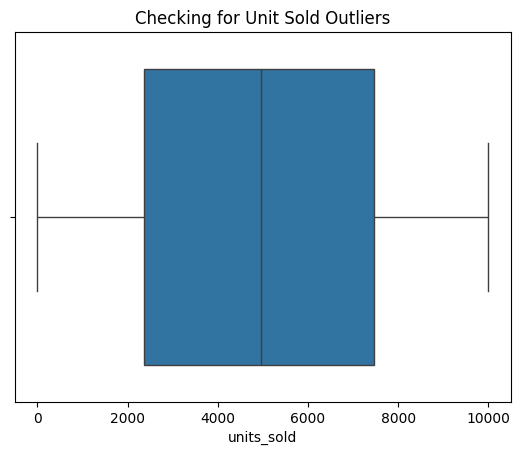

In [ ]:
sns.boxplot(x=events['units_sold'])
plt.title('Checking for Unit Sold Outliers')
plt.show()

There are **no outliers found**:
- `order_date` and `ship_date`: These columns were not analyzed for outliers as they represent timeline markers rather than quantitative values for calculation.
- `units_sold`:
  - The minimum is 2 items, and the maximum is 9,999 items per order.
  - While 9,999 is high, it doesn't seem to be an outlier. Usually, "fake" data or errors are represented by 'impossible' values like -999; And 9,999 falls within a realistic range. Additionally, the boxplot confirmed that these points stay within the whiskers.
- `unit_cost` and `unit_price`:
  - These don't seem to be outliers. The values represent standard product pricing.
  - *Note:* While the maximums are higher than the mean, they rather represent more expensive products rather than incorrect or corrupted data.

### 2.3. Data cleaning - Products Table

In [ ]:
# Checking for NaN values
print(products.isna().sum())

id           0
item_type    0
dtype: int64


Since we don't plan to do any calculations with order_id and product_id, it's better to make them string values (as it's a better practice).

In [ ]:
products["id"] = products["id"].astype(str)

In [ ]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         12 non-null     object
 1   item_type  12 non-null     object
dtypes: object(2)
memory usage: 324.0+ bytes


In [ ]:
# Standardising columns that contain strings
products["item_type"] = products["item_type"].str.strip().str.title()

# Replacing all cyryllic to latin letters
products["item_type"] = products["item_type"].replace(similar_letters, regex=True)

In [ ]:
products_duplicated = products.duplicated()
products_duplicated.sum()

np.int64(0)

Based on our results, there are neither missed nor duplicated values in Products table.

# Step 3: Data analysis and visualization

### 3.1. Joining tables into one table

In [ ]:
# Left Merging all 3 tables
events_and_countries = (events.merge(countries[["name", "alpha_3", "region", "sub_region"]], left_on="country_code", right_on="alpha_3", how="left"))
all_tables = (events_and_countries.merge(products[["id", "item_type"]], left_on="product_id", right_on="id", how="left"))

In [ ]:
# Reviewing if the joining went successful
all_tables.head(2)

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,name,alpha_3,region,sub_region,id,item_type
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650.00,205.70,117.11,Norway,NOR,Europe,Northern Europe,2103,Cereal
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,"1,993.00",205.70,117.11,Serbia,SRB,Europe,Southern Europe,2103,Cereal


In [ ]:
# Deleting unnecessary (duplicated) columns
data = all_tables.drop(columns=["product_id", "alpha_3", "id"])
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        1330 non-null   object        
 1   order_date      1330 non-null   datetime64[ns]
 2   ship_date       1330 non-null   datetime64[ns]
 3   order_priority  1330 non-null   object        
 4   country_code    1330 non-null   object        
 5   sales_channel   1330 non-null   object        
 6   units_sold      1330 non-null   float64       
 7   unit_price      1330 non-null   float64       
 8   unit_cost       1330 non-null   float64       
 9   name            1248 non-null   object        
 10  region          1248 non-null   object        
 11  sub_region      1248 non-null   object        
 12  item_type       1330 non-null   object        
dtypes: datetime64[ns](2), float64(3), object(8)
memory usage: 135.2+ KB


In [ ]:
# Checking for NaN values after conducting the Left Join
data.isna().sum()

,0
order_id,0
order_date,0
ship_date,0
order_priority,0
country_code,0
sales_channel,0
units_sold,0
unit_price,0
unit_cost,0
name,82


We used LEFT JOIN to keep all data from the Events table.

However, since some of the country codes were missing, after merging, we got 'NaN' values. Since we know that we shouldn't delete 82 values (out of 1,330), we need to additionally replace NaN with Unknown (as they appear in 'object' columns)

In [ ]:
data = data.fillna('UNKNOWN')
data.isna().sum()

,0
order_id,0
order_date,0
ship_date,0
order_priority,0
country_code,0
sales_channel,0
units_sold,0
unit_price,0
unit_cost,0
name,0


In [ ]:
# Change some columns names to make them better explain the data
data = data.rename(
    columns={
        'name': 'country',
        'item_type': 'product'
    }
)

In [ ]:
# Adding columns that we'll need for further calculations

data["order_month"] = data["order_date"].dt.to_period('M')
data["order_quarter"] = data["order_date"].dt.to_period('Q')
data["order_year"] = data["order_date"].dt.to_period('Y')

data["weekday"] = data["order_date"].dt.day_name()

We finished with the data merging and cleaning, so we can proceed with the analysis.

### 3.2. Key Metrics of Company's business activity

In [ ]:
# Key Metrics: Totals p.1

data["total_revenue"] = data["units_sold"] * data["unit_price"]
data["total_cost"] = data["units_sold"] * data["unit_cost"]
data["total_profit"] = data["total_revenue"] - data["total_cost"]

total_revenue = data["total_revenue"].sum()
total_cost = data["total_cost"].sum()
total_profit = data["total_profit"].sum()

print(f"Total Revenue: ${total_revenue: ,.2f}\nTotal Cost: ${total_cost: ,.2f}\nTotal Profit: ${total_profit: ,.2f}\n ")

Total Revenue: $ 1,704,628,370.65
Total Cost: $ 1,202,785,737.53
Total Profit: $ 501,842,633.12
 


In [ ]:
# Key Metrics: Totals p.2

total_orders = data["order_id"].count()
total_units_sold = data["units_sold"].sum()
total_countries = data[data["country"] != 'UNKNOWN']["country"].nunique() # applied filter to hide 'Unknown' values
total_sub_regions = data[data["sub_region"] != 'UNKNOWN']["sub_region"].nunique() # applied filter to hide 'Unknown' values
total_regions = data[data["region"] != 'UNKNOWN']["region"].nunique() # applied filter to hide 'Unknown' values
total_products = data['product'].nunique()

print(f"Total Orders Number: {total_orders: ,.0f}")
print(f"Total Units Sold: {total_units_sold: ,.0f}")
print(f"\nCompany sells products to {total_countries} countries across {total_sub_regions} sub-regions in {total_regions} regions")
print(f"\nCompany sells {total_products} (unique) products")

Total Orders Number:  1,330
Total Units Sold:  6,586,448

Company sells products to 45 countries across 5 sub-regions in 2 regions

Company sells 12 (unique) products


In [ ]:
# Key Metrics: Averages p.1
average_order_revenue = data["total_revenue"].mean()
average_order_cost = data["total_cost"].mean()
average_order_profit = data["total_profit"].mean()

print(f"Average revenue per order: ${average_order_revenue: ,.2f}\nAverage cost per order: ${average_order_cost: ,.2f}\nAverage profit per order: ${average_order_profit: ,.2f}\n")

average_units_sold = data["units_sold"].mean()
average_gross_margin = (total_profit / total_revenue) * 100

print(f"Average units sold per order: {average_units_sold: ,.2f}\nAverage gross margin: {average_gross_margin: ,.2f}%")

Average revenue per order: $ 1,281,675.47
Average cost per order: $ 904,350.18
Average profit per order: $ 377,325.29

Average units sold per order:  4,952.22
Average gross margin:  29.44%


In [ ]:
# Key Metrics: Averages p.2
data["delivery_time"] = (data["ship_date"] - data["order_date"]).dt.days
average_delivery_time = data["delivery_time"].mean()

print(f"Average Delivery Time: {average_delivery_time:,.2f} days")

Average Delivery Time: 24.78 days


### 3.3. Sales Analysis

As we'll dive deeper into analysis, it's preferred to filter and hide data from the Unknown countries, sub-regions, and regions.

Let's create a new dataframe that contains only known data, so we don't need to duplicate the filtration each time.

In [ ]:
known_data = data[(data["country"] != 'UNKNOWN') & (data["sub_region"] != 'UNKNOWN') & (data["region"] != 'UNKNOWN')]
known_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1248 entries, 0 to 1329
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        1248 non-null   object        
 1   order_date      1248 non-null   datetime64[ns]
 2   ship_date       1248 non-null   datetime64[ns]
 3   order_priority  1248 non-null   object        
 4   country_code    1248 non-null   object        
 5   sales_channel   1248 non-null   object        
 6   units_sold      1248 non-null   float64       
 7   unit_price      1248 non-null   float64       
 8   unit_cost       1248 non-null   float64       
 9   country         1248 non-null   object        
 10  region          1248 non-null   object        
 11  sub_region      1248 non-null   object        
 12  product         1248 non-null   object        
 13  order_month     1248 non-null   period[M]     
 14  order_quarter   1248 non-null   period[Q-DEC] 
 15  order_yea

### 3.3.1. Sales by Product

In [ ]:
sales_by_product = pd.pivot_table(known_data,
                                  index="product",
                                  values=["order_id", "units_sold", "total_revenue", "total_cost", "total_profit"],
                                  aggfunc={
                                      "order_id": 'count',
                                      "units_sold": 'sum',
                                      "total_revenue": 'sum',
                                      "total_cost": 'sum',
                                      "total_profit": 'sum'
                                      }
                                  )
sales_by_product = sales_by_product[["order_id", "units_sold", "total_revenue", "total_cost", "total_profit"]]

sales_by_product.head(2)

,order_id,units_sold,total_revenue,total_cost,total_profit
product,,,,,
Baby Food,105,"524,265.00","133,834,369.20","83,578,326.30","50,256,042.90"
Beverages,113,"577,991.00","27,425,672.95","18,374,333.89","9,051,339.06"


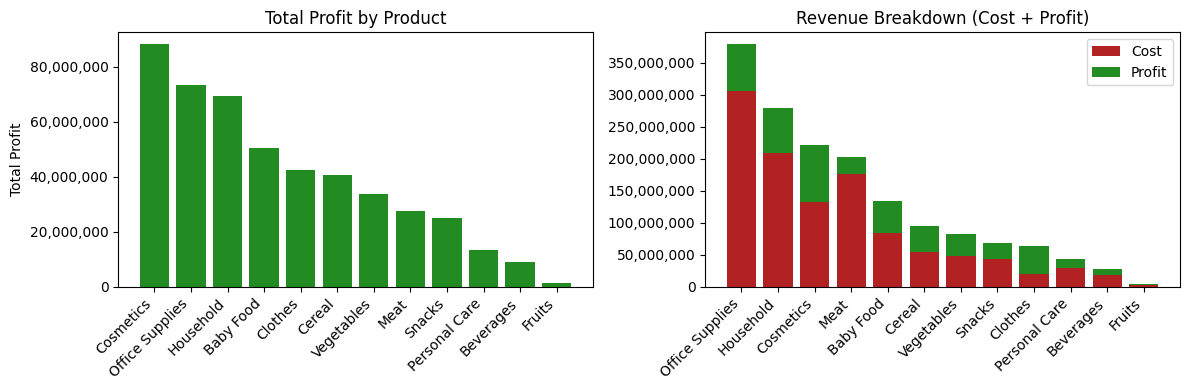

In [ ]:
# Creating vizualizations
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Sorting data for 1st subplot:
sales_by_product_sort_by_profit = sales_by_product.reset_index().sort_values(by="total_profit", ascending=False)

# First subplot - Bar plot
ax[0].bar(sales_by_product_sort_by_profit["product"], sales_by_product_sort_by_profit["total_profit"], color='forestgreen')
ax[0].set_title("Total Profit by Product")
ax[0].set_xticks(range(len(sales_by_product_sort_by_profit)))
ax[0].set_xticklabels(sales_by_product_sort_by_profit["product"], rotation=45, ha='right')
ax[0].set_ylabel("Total Profit")
ax[0].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

#Sorting data for 2nd subplot
sales_by_product_sort_by_revenue = sales_by_product.reset_index().sort_values(by="total_revenue", ascending=False)
sales_by_product_sort_by_revenue

# Second subplot - Combined Bar Plot:
ax[1].bar(sales_by_product_sort_by_revenue["product"], sales_by_product_sort_by_revenue["total_cost"], label='Cost', color='firebrick')
ax[1].bar(sales_by_product_sort_by_revenue["product"], sales_by_product_sort_by_revenue["total_profit"], bottom=sales_by_product_sort_by_revenue["total_cost"], label='Profit', color='forestgreen')
ax[1].set_title("Revenue Breakdown (Cost + Profit)")
ax[1].set_xticks(range(len(sales_by_product_sort_by_revenue)))
ax[1].set_xticklabels(sales_by_product_sort_by_revenue["product"], rotation=45, ha='right')
ax[1].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
ax[1].legend()

plt.tight_layout()

# Show plots
plt.show()

The first graph shows that the most profitable product is Cosmetics, while the least profitable is Fruits.

On the second graph, we can see that even though Office Supplies and Household products generate higher revenue, Cosmetics is more profitable. As a result, despite having lower revenue, it shows higher net profit results.

### 3.3.2. Sales by country

In [ ]:
sales_by_country = pd.pivot_table(known_data,
                                  index="country",
                                  values=["order_id", "units_sold", "total_revenue", "total_cost", "total_profit"],
                                  aggfunc={
                                      "order_id": 'count',
                                      "units_sold": 'sum',
                                      "total_revenue": 'sum',
                                      "total_cost": 'sum',
                                      "total_profit": 'sum'
                                      }
                                  )
sales_by_country = sales_by_country[["order_id", "units_sold", "total_revenue", "total_cost", "total_profit"]]

sales_by_country.head()

,order_id,units_sold,total_revenue,total_cost,total_profit
country,,,,,
Albania,21,"90,608.00","32,224,853.87","21,734,147.85","10,490,706.02"
Andorra,40,"185,686.00","47,756,693.17","32,346,656.54","15,410,036.63"
Armenia,29,"150,665.00","37,519,840.21","28,097,487.03","9,422,353.18"
Austria,28,"145,573.00","35,740,871.49","25,713,361.85","10,027,509.64"
Belarus,28,"153,432.00","34,236,260.77","22,383,839.72","11,852,421.05"


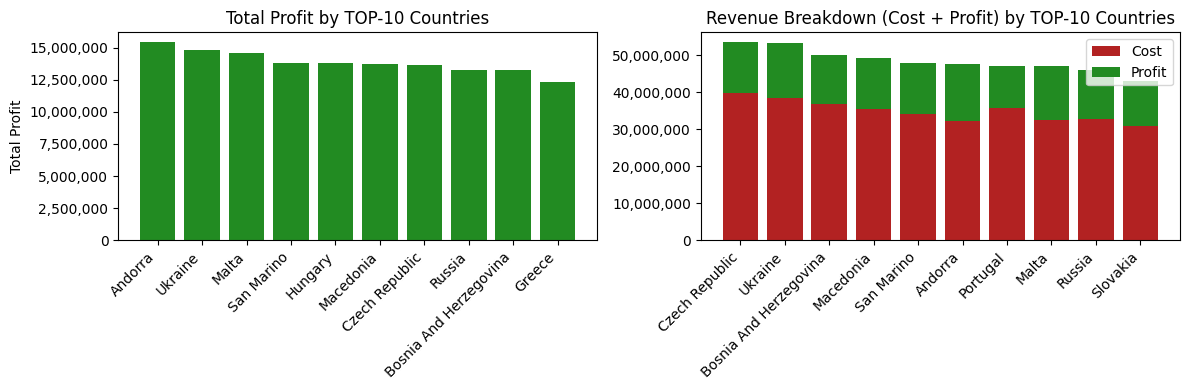

In [ ]:
# Creating vizualizations
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Sorting data for 1st subplot (TOP-10):
sales_by_country_sort_by_profit = sales_by_country.reset_index().sort_values(by="total_profit", ascending=False).head(10)

# First subplot - Bar plot
ax[0].bar(sales_by_country_sort_by_profit["country"], sales_by_country_sort_by_profit["total_profit"], color='forestgreen')
ax[0].set_title("Total Profit by TOP-10 Countries")
ax[0].set_xticks(range(len(sales_by_country_sort_by_profit)))
ax[0].set_xticklabels(sales_by_country_sort_by_profit["country"], rotation=45, ha='right')
ax[0].set_ylabel("Total Profit")
ax[0].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

#Sorting data for 2nd subplot (TOP-10):
sales_by_country_sort_by_revenue = sales_by_country.reset_index().sort_values(by="total_revenue", ascending=False).head(10)

# Second subplot - Combined Bar Plot:
ax[1].bar(sales_by_country_sort_by_revenue["country"], sales_by_country_sort_by_revenue["total_cost"], label='Cost', color='firebrick')
ax[1].bar(sales_by_country_sort_by_revenue["country"], sales_by_country_sort_by_revenue["total_profit"], bottom=sales_by_country_sort_by_revenue["total_cost"], label='Profit', color='forestgreen')
ax[1].set_title("Revenue Breakdown (Cost + Profit) by TOP-10 Countries")
ax[1].set_xticks(range(len(sales_by_country_sort_by_revenue)))
ax[1].set_xticklabels(sales_by_country_sort_by_revenue["country"], rotation=45, ha='right')
ax[1].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
ax[1].legend()

plt.tight_layout()

# Show plots
plt.show()

The first graph shows that Andorra and Ukraine generate the greatest profit. At the same time, the second graph shows that the Czech Republic generates higher revenue. However, since it purchases less profitable products, it ranks lower in terms of net profit.

### 3.3.3. Sales by sub-region

In [ ]:
sales_by_sub_region = pd.pivot_table(known_data,
                                  index="sub_region",
                                  values=["order_id", "units_sold", "total_revenue", "total_cost", "total_profit"],
                                  aggfunc={
                                      "order_id": 'count',
                                      "units_sold": 'sum',
                                      "total_revenue": 'sum',
                                      "total_cost": 'sum',
                                      "total_profit": 'sum'
                                      }
                                  )
sales_by_sub_region = sales_by_sub_region[["order_id", "units_sold", "total_revenue", "total_cost", "total_profit"]]

sales_by_sub_region

,order_id,units_sold,total_revenue,total_cost,total_profit
sub_region,,,,,
Eastern Europe,271,"1,349,811.00","378,686,527.47","267,413,890.91","111,272,636.56"
Northern Europe,259,"1,244,958.00","296,410,776.24","205,216,928.20","91,193,848.04"
Southern Europe,413,"2,136,277.00","564,531,246.55","397,826,623.75","166,704,622.80"
Western Asia,82,"410,427.00","93,330,887.37","68,178,634.42","25,152,252.95"
Western Europe,223,"1,040,122.00","268,523,286.07","188,729,437.24","79,793,848.83"


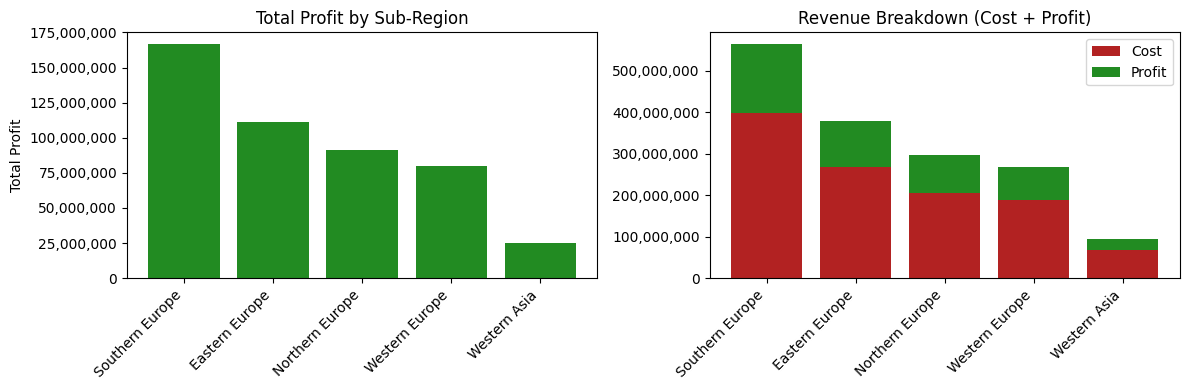

In [ ]:
# Creating vizualizations
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Sorting data for 1st subplot:
sales_by_sub_region_sort_by_profit = sales_by_sub_region.reset_index().sort_values(by="total_profit", ascending=False)

# First subplot - Bar plot
ax[0].bar(sales_by_sub_region_sort_by_profit["sub_region"], sales_by_sub_region_sort_by_profit["total_profit"], color='forestgreen')
ax[0].set_title("Total Profit by Sub-Region")
ax[0].set_xticks(range(len(sales_by_sub_region_sort_by_profit)))
ax[0].set_xticklabels(sales_by_sub_region_sort_by_profit["sub_region"], rotation=45, ha='right')
ax[0].set_ylabel("Total Profit")
ax[0].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

#Sorting data for 2nd subplot:
sales_by_sub_region_by_revenue = sales_by_sub_region.reset_index().sort_values(by="total_revenue", ascending=False).head(10)
sales_by_sub_region_by_revenue

# Second subplot - Combined Bar Plot:
ax[1].bar(sales_by_sub_region_by_revenue["sub_region"], sales_by_sub_region_by_revenue["total_cost"], label='Cost', color='firebrick')
ax[1].bar(sales_by_sub_region_by_revenue["sub_region"], sales_by_sub_region_by_revenue["total_profit"], bottom=sales_by_sub_region_by_revenue["total_cost"], label='Profit', color='forestgreen')
ax[1].set_title("Revenue Breakdown (Cost + Profit)")
ax[1].set_xticks(range(len(sales_by_sub_region_by_revenue)))
ax[1].set_xticklabels(sales_by_sub_region_by_revenue["sub_region"], rotation=45, ha='right')
ax[1].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
ax[1].legend()

plt.tight_layout()

# Show plots
plt.show()

The first graph shows that Southern Europe generates the greatest profit.

The second graph shows that the ranking of sub-regions by profit is similar to the ranking by revenue, which may indicate that sub-regions purchase similar mix of products with comparable profitability.

### 3.3.4. Sales by region

In [ ]:
sales_by_region = pd.pivot_table(known_data,
                                  index="region",
                                  values=["order_id", "units_sold", "total_revenue", "total_cost", "total_profit"],
                                  aggfunc={
                                      "order_id": 'count',
                                      "units_sold": 'sum',
                                      "total_revenue": 'sum',
                                      "total_cost": 'sum',
                                      "total_profit": 'sum'
                                      }
                                  )
sales_by_region = sales_by_region[["order_id", "units_sold", "total_revenue", "total_cost", "total_profit"]]

sales_by_region

,order_id,units_sold,total_revenue,total_cost,total_profit
region,,,,,
Asia,82,"410,427.00","93,330,887.37","68,178,634.42","25,152,252.95"
Europe,1166,"5,771,168.00","1,508,151,836.33","1,059,186,880.10","448,964,956.23"


In [ ]:
sales_by_region = sales_by_region.reset_index()

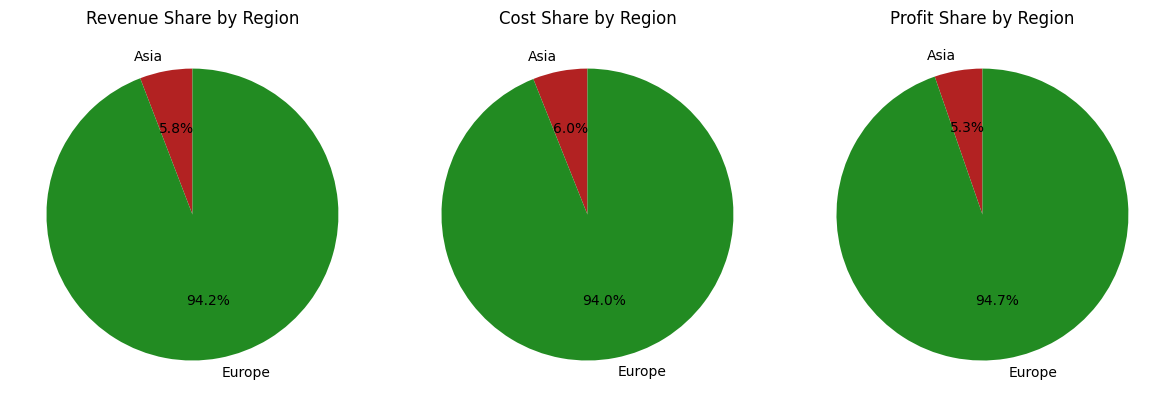

In [ ]:
# Creating vizualizations
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

region_colors = ['firebrick', 'forestgreen']

# First subplot - Pie plot - Revenue Share
ax[0].pie(sales_by_region["total_revenue"], labels=sales_by_region["region"], autopct='%1.1f%%', colors=region_colors, startangle=90)
ax[0].set_title("Revenue Share by Region")

# Second subplot - Pie plot - Cost Share
ax[1].pie(sales_by_region["total_cost"], labels=sales_by_region["region"], autopct='%1.1f%%', colors=region_colors, startangle=90)
ax[1].set_title("Cost Share by Region")

# Third subplot - Pie plot - Profit Share
ax[2].pie(sales_by_region["total_profit"], labels=sales_by_region["region"], autopct='%1.1f%%', colors=region_colors, startangle=90)
ax[2].set_title("Profit Share by Region")

plt.tight_layout()

# Show plots
plt.show()

All graphs show that Europe has a much higher share (+- 94%) of the company's total revenue, costs, and profit compared with Asia (+- 6%).

### 3.3.5. Sales by Sales Channel

In [ ]:
sales_by_channel = pd.pivot_table(known_data,
                                  index="sales_channel",
                                  values=["order_id", "units_sold", "total_revenue", "total_cost", "total_profit"],
                                  aggfunc={
                                      "order_id": 'count',
                                      "units_sold": 'sum',
                                      "total_revenue": 'sum',
                                      "total_cost": 'sum',
                                      "total_profit": 'sum'
                                      }
                                  )
sales_by_channel = sales_by_channel.sort_values(by="sales_channel")
sales_by_channel = sales_by_channel[["order_id", "units_sold", "total_revenue", "total_cost", "total_profit"]]

sales_by_channel

,order_id,units_sold,total_revenue,total_cost,total_profit
sales_channel,,,,,
Offline,623,"3,123,336.00","812,529,427.68","573,609,926.15","238,919,501.53"
Online,625,"3,058,259.00","788,953,296.02","553,755,588.37","235,197,707.65"


In [ ]:
sales_by_channel = sales_by_channel.reset_index()

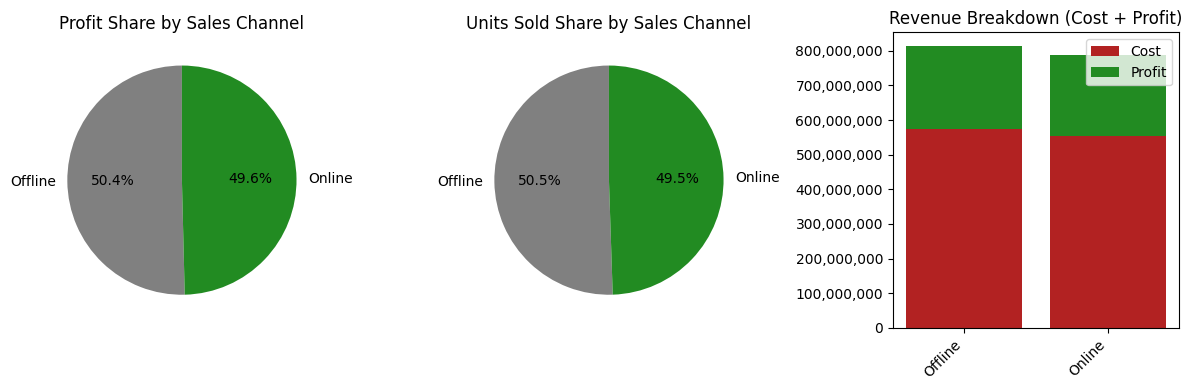

In [ ]:
# Creating vizualizations
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

# Adding the color palette for the plots. Grey stands for offline; green for online
channel_colors = ['grey', "forestgreen"]

ax[0].pie(sales_by_channel["total_profit"], labels=sales_by_channel["sales_channel"], autopct='%1.1f%%', colors=channel_colors, startangle=90)
ax[0].set_title("Profit Share by Sales Channel")

ax[1].pie(sales_by_channel["units_sold"], labels=sales_by_channel["sales_channel"], autopct='%1.1f%%', colors=channel_colors, startangle=90)
ax[1].set_title("Units Sold Share by Sales Channel")

ax[2].bar(sales_by_channel["sales_channel"], sales_by_channel["total_cost"], label='Cost', color='firebrick')
ax[2].bar(sales_by_channel["sales_channel"], sales_by_channel["total_profit"], bottom=sales_by_channel["total_cost"], label='Profit', color='forestgreen')
ax[2].set_title("Revenue Breakdown (Cost + Profit)")
ax[2].set_xticks(range(len(sales_by_channel)))
ax[2].set_xticklabels(sales_by_channel["sales_channel"], rotation=45, ha='right')
ax[2].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
ax[2].legend()

plt.tight_layout()

# Show plots
plt.show()

The distribution between online and offline sales channels in all key metrics is almost equal (the difference looks more like a statistical error than an actual difference).

### 3.4.1. Delivery Time Analysis by Product

In [ ]:
product_sales_by_delivery_time = pd.pivot_table(known_data,
                                  index="product",
                                  values=["delivery_time", "total_profit"],
                                  aggfunc={
                                      "delivery_time": 'mean',
                                      "total_profit": 'sum'
                                      }
                                  )
product_sales_by_delivery_time = product_sales_by_delivery_time[["delivery_time", "total_profit"]]

product_sales_by_delivery_time.head(2)

,delivery_time,total_profit
product,,
Baby Food,26.65,"50,256,042.90"
Beverages,23.95,"9,051,339.06"


In [ ]:
product_sales_by_delivery_time = product_sales_by_delivery_time.reset_index()

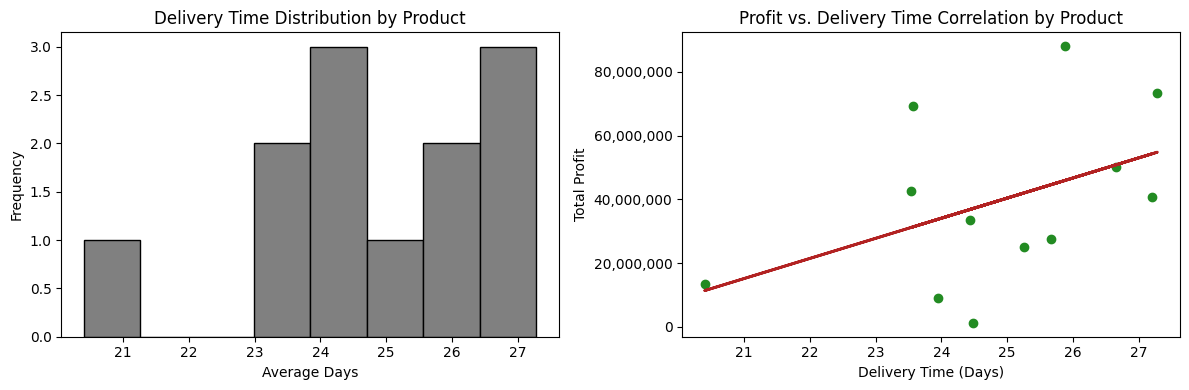

In [ ]:
# Creating vizualizations
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Delivery Time Distribution (Histogram)
ax[0].hist(product_sales_by_delivery_time['delivery_time'], bins=8, color='grey', edgecolor='black')
ax[0].set_title('Delivery Time Distribution by Product')
ax[0].set_xlabel('Average Days')
ax[0].set_ylabel('Frequency')

# Correlation check between profit and delivery time

z = np.polyfit(product_sales_by_delivery_time['delivery_time'], product_sales_by_delivery_time['total_profit'], 1)
p = np.poly1d(z)

ax[1].scatter(product_sales_by_delivery_time['delivery_time'],
              product_sales_by_delivery_time['total_profit'],
              color='forestgreen')

ax[1].plot(product_sales_by_delivery_time['delivery_time'], p(product_sales_by_delivery_time['delivery_time']), color="firebrick", linewidth=2, label='Trend') # The Trend Line
ax[1].set_title('Profit vs. Delivery Time Correlation by Product')
ax[1].set_xlabel('Delivery Time (Days)')
ax[1].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
ax[1].set_ylabel('Total Profit')

plt.tight_layout()
plt.show()

The most frequent delivery times among products are **24 and 27 days**.

There might be a weak positive correlation indicating that the more total profit a product generates, the longer it takes to ship.

### 3.4.2. Delivery Time Analysis by Country

In [ ]:
country_sales_by_delivery_time = pd.pivot_table(known_data,
                                  index="country",
                                  values=["delivery_time", "total_profit"],
                                  aggfunc={
                                      "delivery_time": 'mean',
                                      "total_profit": 'sum'
                                      }
                                  )
country_sales_by_delivery_time = country_sales_by_delivery_time[["delivery_time", "total_profit"]]

country_sales_by_delivery_time.head()

,delivery_time,total_profit
country,,
Albania,26.19,"10,490,706.02"
Andorra,26.27,"15,410,036.63"
Armenia,26.17,"9,422,353.18"
Austria,28.50,"10,027,509.64"
Belarus,25.25,"11,852,421.05"


In [ ]:
country_sales_by_delivery_time = country_sales_by_delivery_time.reset_index()

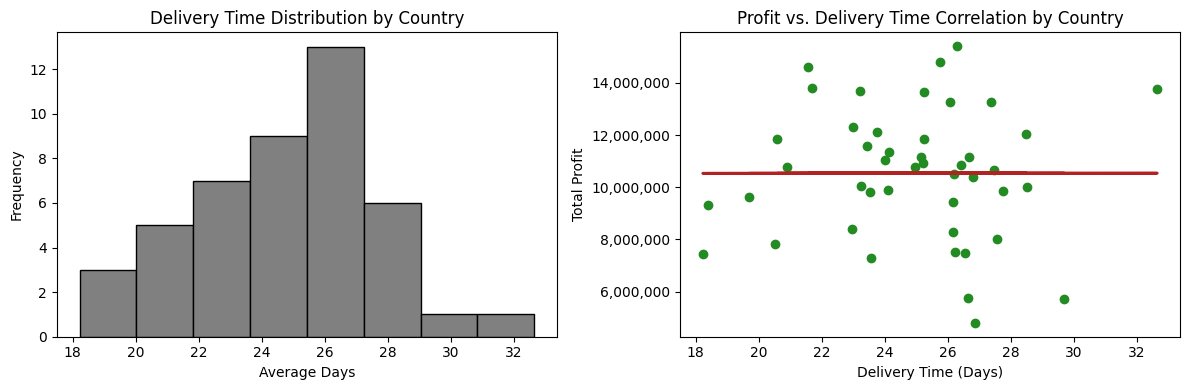

In [ ]:
# Creating vizualizations
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Delivery Time Distribution (Histogram)
ax[0].hist(country_sales_by_delivery_time['delivery_time'], bins=8, color='grey', edgecolor='black')
ax[0].set_title('Delivery Time Distribution by Country')
ax[0].set_xlabel('Average Days')
ax[0].set_ylabel('Frequency')

# Correlation check between profit and delivery time

z = np.polyfit(country_sales_by_delivery_time['delivery_time'], country_sales_by_delivery_time['total_profit'], 1)
p = np.poly1d(z)

ax[1].scatter(country_sales_by_delivery_time['delivery_time'],
              country_sales_by_delivery_time['total_profit'],
              color='forestgreen')
ax[1].plot(country_sales_by_delivery_time['delivery_time'], p(country_sales_by_delivery_time['delivery_time']), color="firebrick", linewidth=2, label='Trend') # The Trend Line

ax[1].set_title('Profit vs. Delivery Time Correlation by Country')
ax[1].set_xlabel('Delivery Time (Days)')
ax[1].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
ax[1].set_ylabel('Total Profit')

plt.tight_layout()
plt.show()

The most frequent delivery time among countries is **26 days**.

There is no correlation between the total profit a country generates and delivery time.

### 3.4.3. Delivery Time Analysis by Region

In [ ]:
region_sales_by_delivery_time = pd.pivot_table(known_data,
                                  index="region",
                                  values=["delivery_time", "total_profit"],
                                  aggfunc={
                                      "delivery_time": 'mean',
                                      "total_profit": 'sum'
                                      }
                                  )
region_sales_by_delivery_time = region_sales_by_delivery_time[["delivery_time", "total_profit"]]

region_sales_by_delivery_time

,delivery_time,total_profit
region,,
Asia,26.09,"25,152,252.95"
Europe,24.78,"448,964,956.23"


In [ ]:
region_sales_by_delivery_time = region_sales_by_delivery_time.reset_index()

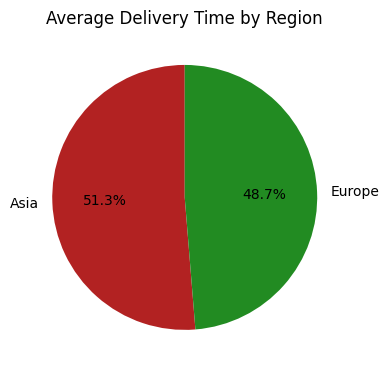

In [ ]:
# Creating vizualizations
fig = plt.figure(figsize=(4, 4))

region_colors = ['firebrick', 'forestgreen']

plt.pie(region_sales_by_delivery_time["delivery_time"], labels=region_sales_by_delivery_time["region"], autopct='%1.1f%%', colors=region_colors, startangle=90)
plt.title("Average Delivery Time by Region")

plt.tight_layout()
plt.show()

### 3.5.1. Checking general Profit vs Delivery Time correlation

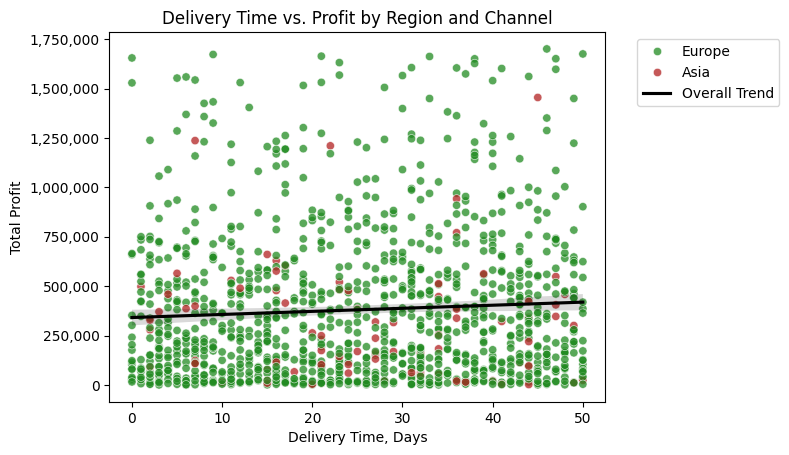

In [ ]:
region_colors = ['forestgreen', 'firebrick']

z = np.polyfit(known_data['delivery_time'], known_data['total_profit'], 1)
p = np.poly1d(z)

sns.scatterplot(data=known_data,
                x="delivery_time",
                y="total_profit",
                hue="region",       # Colors the dots by region
                palette=region_colors,
                alpha=0.75          # Transparency to show dots concentrations
                )

sns.regplot(data=known_data,
            x="delivery_time",
            y="total_profit",
            scatter=False,
            color="black",
            label="Overall Trend")

plt.title("Delivery Time vs. Profit by Region and Channel")
plt.xlabel('Delivery Time, Days')
plt.ylabel('Total Profit')
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Move legend outside of the chart
plt.show()

Overall, there is no correlation between profit and delivery time.

### 3.5.2 Checking Order priotiry vs Delivery Time correlation
Hypothesis: the higher the order priority, the shorter the delivery time will be.

In [ ]:
known_data.head(2)

,order_id,order_date,ship_date,order_priority,country_code,sales_channel,units_sold,unit_price,unit_cost,country,...,sub_region,product,order_month,order_quarter,order_year,weekday,total_revenue,total_cost,total_profit,delivery_time
0,100640618,2014-10-08,2014-10-18,M,NOR,Online,650.00,205.70,117.11,Norway,...,Northern Europe,Cereal,2014-10,2014Q4,2014,Wednesday,"133,705.00","76,121.50","57,583.50",10
1,100983083,2016-08-11,2016-08-11,C,SRB,Offline,"1,993.00",205.70,117.11,Serbia,...,Southern Europe,Cereal,2016-08,2016Q3,2016,Thursday,"409,960.10","233,400.23","176,559.87",0


In [ ]:
delivery_vs_priority = known_data.groupby("order_priority")["delivery_time"].mean()
delivery_vs_priority

,delivery_time
order_priority,
C,23.64
H,24.35
L,25.34
M,25.97


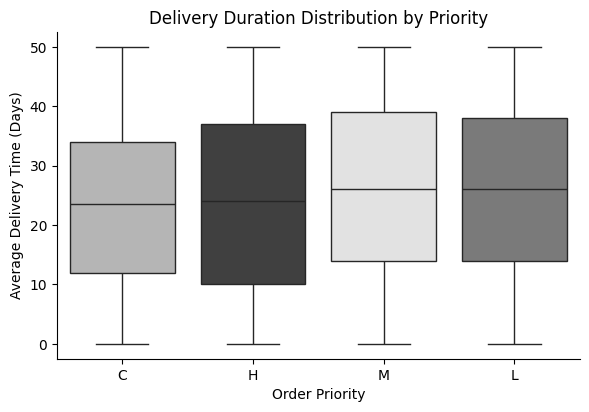

In [ ]:
g = sns.catplot(
    data=known_data,
    x='order_priority',
    y='delivery_time',
    hue='order_priority',
    kind='box',
    order=['C', 'H', 'M', 'L'],
    palette='Greys',
    height=4,
    aspect=1.5
)

plt.title("Delivery Duration Distribution by Priority")
plt.xlabel('Order Priority')
plt.ylabel('Average Delivery Time (Days)')

plt.show()

The graph shows that there is **no significant difference in delivery time among orders with different priorities**. Based on this, we can't confirm our hypothesis, and we can't say that higher priority leads to shorter delivery time.

### 3.6.1. Sales Dynamics by Product

In [ ]:
# Quarterly Dynamics
quarterly_product_sales_dynamics = pd.pivot_table(known_data,
                                  index="product",
                                  columns="order_quarter",
                                  values="total_profit",
                                  aggfunc='sum'
                                  )
quarterly_product_sales_dynamics.head(2)

order_quarter,2010Q1,2010Q2,2010Q3,2010Q4,2011Q1,2011Q2,2011Q3,2011Q4,2012Q1,2012Q2,...,2015Q2,2015Q3,2015Q4,2016Q1,2016Q2,2016Q3,2016Q4,2017Q1,2017Q2,2017Q3
product,,,,,,,,,,,,,,,,,,,,,
Baby Food,"2,690,790.20","1,707,074.88","2,002,611.26","490,611.48","2,669,221.70","1,226,432.84","922,748.36","634,401.48","1,233,047.18","3,346,472.60",...,"3,316,468.42","571,996.62","1,282,702.66","1,448,157.02","855,262.92","1,136,324.44","733,904.16","1,324,401.76","181,175.40",NaN
Beverages,"467,184.78","27,953.10","297,461.70","314,029.98","176,018.40","256,228.92","294,079.14","277,103.70","198,928.98","146,013.84",...,"337,864.50","565,419.96","82,747.44","618,131.52","132,655.86","222,137.10","348,247.08","561,426.66","345,757.14","360,555.84"


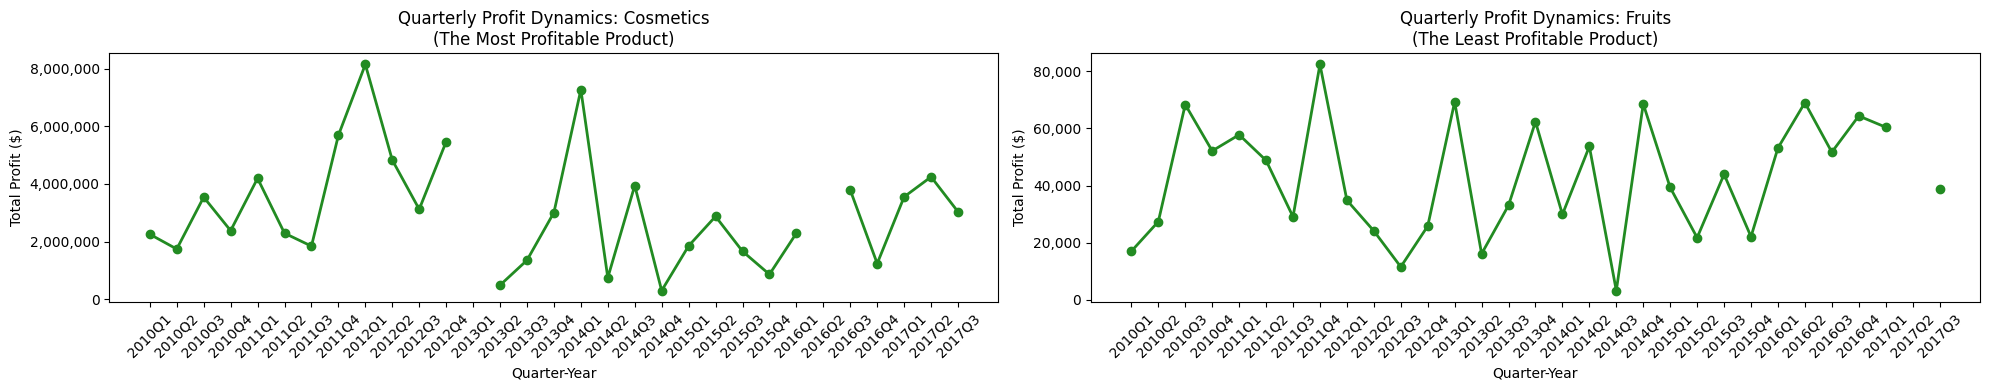

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(20, 4))

# Data for the dynamics of the most profitable product
cosmetics_quarterly = quarterly_product_sales_dynamics.loc['Cosmetics']

ax[0].plot(cosmetics_quarterly.index.astype(str), cosmetics_quarterly.values, marker='o', linewidth=2, color='forestgreen')

ax[0].set_title("Quarterly Profit Dynamics: Cosmetics\n(The Most Profitable Product)")
ax[0].tick_params(axis='x', rotation=45)
ax[0].set_xlabel("Quarter-Year")
ax[0].set_ylabel("Total Profit ($)")
ax[0].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# Data for the dynamics of the least profitable product
fruits_monthly = quarterly_product_sales_dynamics.loc['Fruits']

ax[1].plot(fruits_monthly.index.astype(str), fruits_monthly.values, marker='o', linewidth=2, color='forestgreen')
ax[1].set_title("Quarterly Profit Dynamics: Fruits\n(The Least Profitable Product)")
ax[1].tick_params(axis='x', rotation=45)
ax[1].set_xlabel("Quarter-Year")
ax[1].set_ylabel("Total Profit ($)")
ax[1].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

In general, it seems that both the most and the least profitable products show similar trends in being quite volatile.

There is a risk for the company, as there were months with no profit from the most profitable product, and similar situations can negatively affect the company.

### 3.6.2. Sales Dynamics by Country

In [ ]:
# Yearly Dynamics
yearly_country_sales_dynamics = pd.pivot_table(known_data,
                                  index="country",
                                  columns="order_year",
                                  values="total_profit",
                                  aggfunc='sum'
                                  )
yearly_country_sales_dynamics.head(2)

order_year,2010,2011,2012,2013,2014,2015,2016,2017
country,,,,,,,,
Albania,"2,733,094.76","1,593,784.75","1,805,447.26","108,212.64","81,133.66","1,406,732.31","2,472,438.87","289,861.77"
Andorra,"3,243,222.41","677,799.93","3,423,332.26","1,205,156.65","1,028,468.14","580,266.74","4,601,388.80","650,401.70"
Armenia,"1,930,234.67","903,658.36","1,179,933.37","415,253.58","964,283.24","2,072,917.17","1,142,530.99","813,541.80"
Austria,"3,489,734.81","839,535.12","210,537.95","651,535.22","1,056,415.09","3,022,172.75","485,865.15","271,713.55"
Belarus,"773,377.19","1,875,224.26","1,872,339.31","1,102,328.72","904,792.84","2,339,000.34","2,270,877.27","714,481.12"


In [ ]:
# Adding Total Profit column to check the most profitable countries.
yearly_country_sales_dynamics['Total Profit'] = yearly_country_sales_dynamics.sum(axis=1)
yearly_country_sales_dynamics = yearly_country_sales_dynamics.sort_values(by='Total Profit', ascending=False)
yearly_country_sales_dynamics.head(2)

order_year,2010,2011,2012,2013,2014,2015,2016,2017,Total Profit
country,,,,,,,,,
Andorra,"3,243,222.41","677,799.93","3,423,332.26","1,205,156.65","1,028,468.14","580,266.74","4,601,388.80","650,401.70","15,410,036.63"
Ukraine,"840,103.28","3,598,514.69","3,732,033.07","113,863.86","2,163,209.64","1,314,080.69","1,435,583.60","1,607,536.91","14,804,925.74"


In [ ]:
yearly_country_sales_dynamics = yearly_country_sales_dynamics.reset_index()

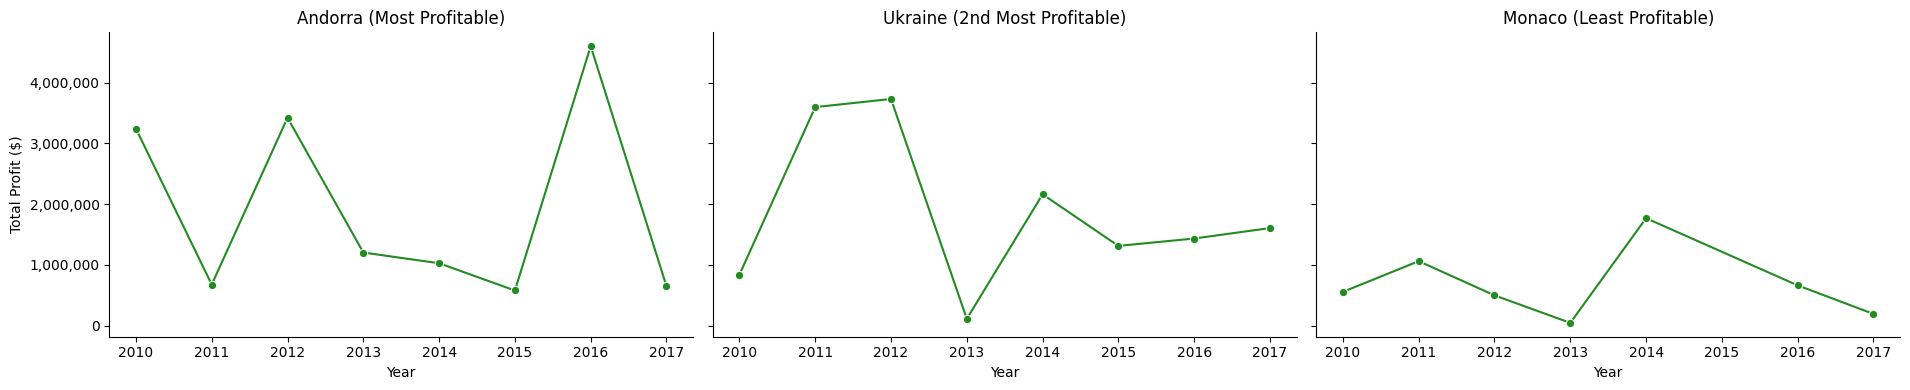

In [ ]:
# Selecting countries for vizualization
target_countries = ['Andorra', 'Ukraine', 'Monaco']
selected_countries = yearly_country_sales_dynamics[yearly_country_sales_dynamics['country'].isin(target_countries)]

# Transfer year to correct format for the relplot
long_titles_list = selected_countries.drop(columns=['Total Profit']).melt(
    id_vars='country',
    var_name='Year',
    value_name='Profit'
)

long_titles_list['Year'] = long_titles_list['Year'].astype(str)

g = sns.relplot(
    data=long_titles_list,
    x='Year',
    y='Profit',
    col='country',
    kind='line',
    marker='o',
    color='forestgreen',
    height=4,
    aspect=1.6
)

# Seaborn automatically puts "country = Andorra" as titles, so we should fix that
axes = g.axes.flatten()
titles = ["Andorra (Most Profitable)", "Ukraine (2nd Most Profitable)", "Monaco (Least Profitable)"]

for ax, title in zip(axes, titles):
    ax.set_title(title)
    ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
    ax.set_ylabel("Total Profit ($)")

plt.tight_layout()

plt.show()


The graphs show that there was a decrease in profit in 2013 (for Andorra, it continued until 2015), but after that, the results improved.

However, 2017 wasn't the most successful year for any of the countries.

### 3.6.3. Sales Dynamics by Region

In [ ]:
# Monthly Dynamics
monthly_region_sales_dynamics = pd.pivot_table(known_data,
                                  index="region",
                                  columns="order_month",
                                  values="total_profit",
                                  aggfunc='sum'
                                  )
monthly_region_sales_dynamics

order_month,2010-01,2010-02,2010-03,2010-04,2010-05,2010-06,2010-07,2010-08,2010-09,2010-10,...,2016-10,2016-11,2016-12,2017-01,2017-02,2017-03,2017-04,2017-05,2017-06,2017-07
region,,,,,,,,,,,,,,,,,,,,,
Asia,"834,826.85","959,065.58",NaN,NaN,"489,532.92",NaN,NaN,NaN,NaN,"564,850.00",...,"19,562.40","529,059.48","550,743.18","361,059.03","465,686.24",NaN,NaN,NaN,"994,844.76",NaN
Europe,"7,455,342.68","3,347,419.49","3,093,055.70","2,320,389.85","5,831,513.78","6,065,111.59","3,871,434.93","3,999,209.52","6,098,575.75","5,631,499.91",...,"2,692,743.84","4,330,678.04","3,124,560.78","5,690,340.80","4,525,107.67","4,453,782.51","3,883,412.87","4,630,878.75","4,253,012.24","6,667,946.79"


In [ ]:
# Yearly Dynamics
yearly_region_sales_dynamics = pd.pivot_table(known_data,
                                  index="region",
                                  columns="order_year",
                                  values="total_profit",
                                  aggfunc='sum'
                                  )
yearly_region_sales_dynamics.reset_index()

order_year,region,2010,2011,2012,2013,2014,2015,2016,2017
0,Asia,"3,503,181.39","1,456,460.18","5,462,681.60","3,720,805.55","3,833,480.30","3,400,170.30","1,953,883.60","1,821,590.03"
1,Europe,"56,314,811.32","62,910,550.76","77,607,374.58","47,501,124.13","62,554,072.98","54,826,339.24","53,146,201.59","34,104,481.63"


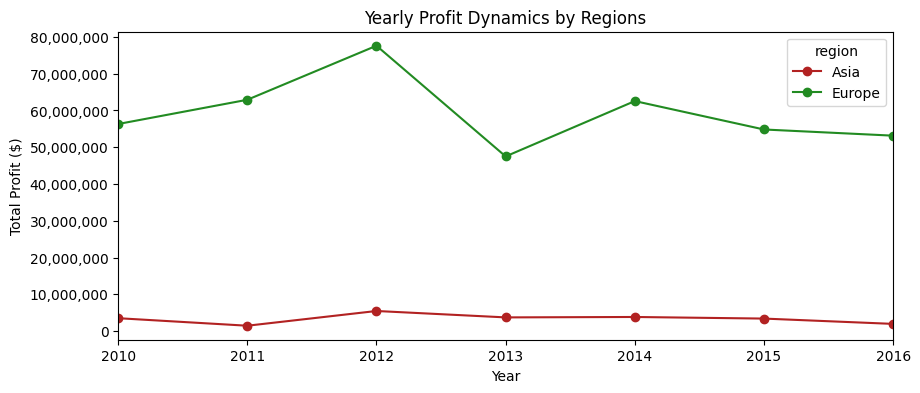

In [ ]:
region_colors = ['firebrick', 'forestgreen']

yearly_region_sales_dynamics.iloc[:, :-1].T.plot(kind='line', marker='o', figsize=(10, 4), color=region_colors)
plt.title('Yearly Profit Dynamics by Regions')
plt.xlabel('Year')
plt.ylabel('Total Profit ($)')
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.show()

While Europe is quite volatile, Asia's yearly profit remains relatively stable. However, we can see a negative tendency in Asia's profit over time (starting in 2012), and Europe's profit also decreases over time (starting in 2014).

### 3.7.1. Sales by Weekday

In [ ]:
sales_by_weekday = pd.pivot_table(known_data,
                                  index="weekday",
                                  values=["order_id", "units_sold", "total_revenue", "total_cost", "total_profit"],
                                  aggfunc={
                                      "order_id": 'count',
                                      "units_sold": 'sum',
                                      "total_revenue": 'sum',
                                      "total_cost": 'sum',
                                      "total_profit": 'sum'
                                      }
                                  )
# Creating a list with the correct days order (by default they're shown alphabetically)
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sales_by_weekday = sales_by_weekday.reindex(days_order)

sales_by_weekday = sales_by_weekday[["order_id", "units_sold", "total_revenue", "total_cost", "total_profit"]]

sales_by_weekday

,order_id,units_sold,total_revenue,total_cost,total_profit
weekday,,,,,
Monday,185,"938,639.00","259,560,672.84","187,279,329.82","72,281,343.02"
Tuesday,175,"838,937.00","206,960,887.63","143,164,194.24","63,796,693.39"
Wednesday,182,"839,870.00","244,867,624.96","177,099,502.53","67,768,122.43"
Thursday,158,"818,022.00","203,247,291.52","143,138,936.20","60,108,355.32"
Friday,163,"787,802.00","243,620,811.05","170,297,383.87","73,323,427.18"
Saturday,191,"970,549.00","220,822,159.56","152,078,974.28","68,743,185.28"
Sunday,194,"987,776.00","222,403,276.14","154,307,193.58","68,096,082.56"


In [ ]:
sales_by_weekday = sales_by_weekday.reset_index()

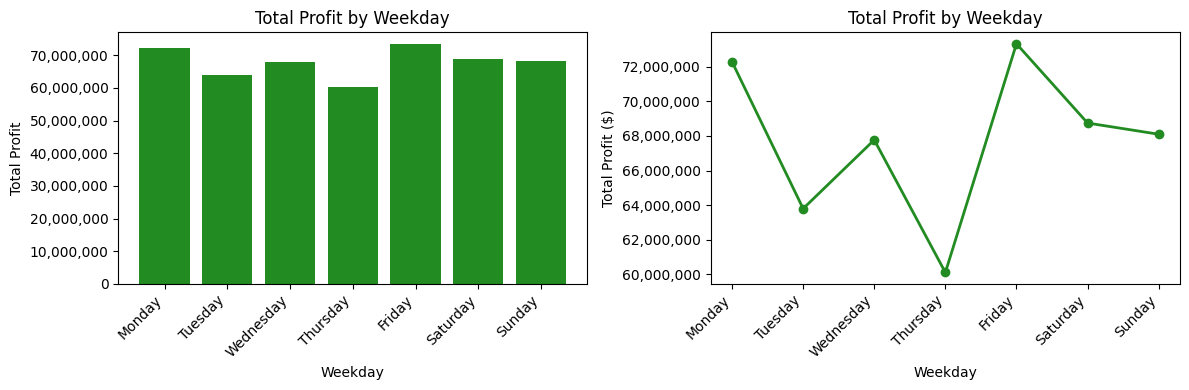

In [ ]:
# Creating vizualizations
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# First subplot - Bar plot
ax[0].bar(sales_by_weekday["weekday"], sales_by_weekday["total_profit"], color='forestgreen')
ax[0].set_title("Total Profit by Weekday")
ax[0].set_xlabel("Weekday")
ax[0].set_xticks(range(len(sales_by_weekday)))
ax[0].set_xticklabels(sales_by_weekday["weekday"], rotation=45, ha='right')
ax[0].set_ylabel("Total Profit")
ax[0].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# Second subplot - Line Plot (dynamics)
ax[1].plot(sales_by_weekday["weekday"], sales_by_weekday["total_profit"], marker='o', linewidth=2, color='forestgreen')

ax[1].set_title("Total Profit by Weekday")
ax[1].set_xlabel("Weekday")
ax[1].set_xticks(range(len(sales_by_weekday)))
ax[1].set_xticklabels(sales_by_weekday["weekday"], rotation=45, ha='right')
ax[1].set_ylabel("Total Profit ($)")
ax[1].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()

# Show plots
plt.show()

The graphs show that Friday is the most profitable day. The worst (lowest) results are during weekdays, especially Tuesday and Thursday.

In [ ]:
product_weekday_seasoning = pd.pivot_table(known_data,
                                  index="product",
                                  columns="weekday",
                                  values="total_profit",
                                  aggfunc="mean"
                                  )
product_weekday_seasoning = product_weekday_seasoning[['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']]

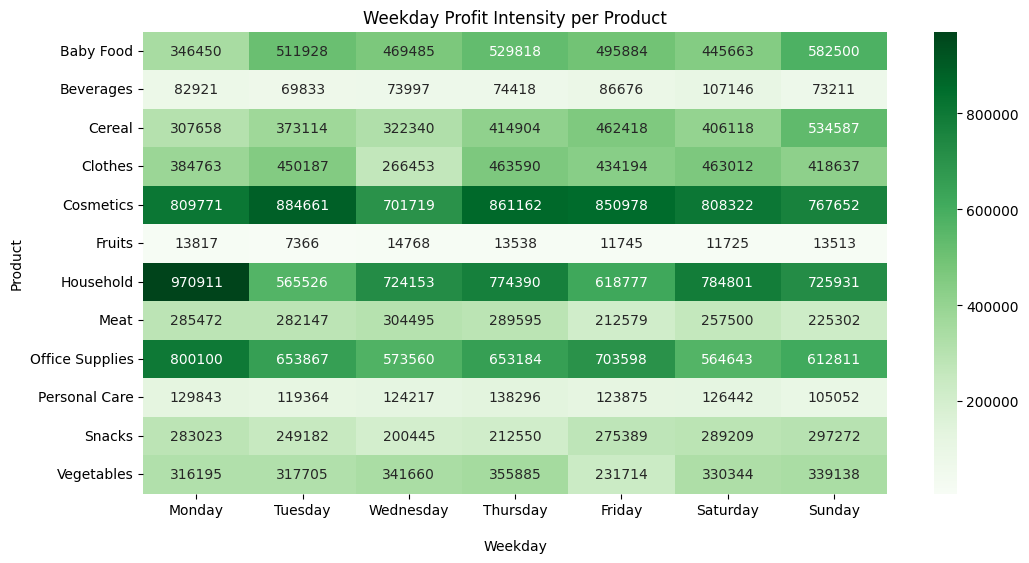

In [ ]:
plt.figure(figsize=(12, 6))
# Heatmap to check weekday seasoning of products sales
sns.heatmap(product_weekday_seasoning, annot=True, fmt=".0f", cmap="Greens")

plt.title("Weekday Profit Intensity per Product")
plt.ylabel(f"Product")
plt.xlabel(f"\nWeekday")
plt.show()

As we can see from the graph, although Friday is not the most successful day for every product category, most products show strong profit results on this day. As a result, this cumulative effect makes Friday the most profitable day overall.

On other days, some categories perform significantly better, which makes those days slightly more profitable compared to the rest.

# 4. Reporting
We analyzed **1,330 orders** generating **$501.8 mln** during **2012-2017**.

### Product Sales:
- **Profitability vs. Revenue**: Analysis revealed that high-revenue products don't always generated the highest profit.
- The most profitable category is Cosmetics (> USD 80 M profit), while Fruits is the least profitable (< USD 1.5 M).

**Strategic Recommendation:** Establish a minimum KPI of 20% profit margin. The company should consider stop selling low-margin products to reallocate operational resources toward high-growth categories.

### Markets (geographic) sales:
- The company operates in 45 countries, with most profit coming **from Europe, especially Southern Europe.**
- The company should either diversify markets or strengthen existing high-performing regions.
- For expansion, **Asia** is preferable over entering new continents, as current presence there is much weaker compared to company's presense in Europe.

**Strategic Recommendation:** Focus operating efforts on the Asian market to diversify revenue streams beyond Europe.

### Sales channels:
- No significant difference exists between **online and offline channels**, so both should be maintained equally.

### Delivery time and product priority:
- There is no correlation between **profit and delivery time**.
- Also, no correlation was found between **order priority and delivery time**, meaning high-priority orders don't require expensive fast shipping.

**Strategic Recommendation:** Optimize shipping costs by transitioning to more cost-effective, "slower" freight methods (e.g., sea freight).

### Sales Dynamics:
- There are gaps in **Cosmetics sales**, possibly due to missing data.
  - If confirmed, this should be fixed.
  - Otherwise, stabilizing Cosmetics performance is important as it generates the highest profit.
- Total profit also shows a slight downward trend, which is **a risk requiring attention.**

### Weekday trends:
- Sales peak from Friday to Monday, while Tuesday and Thursday are weakest.

**Strategic Recommendation:**
- Run marketing campaigns on Fridays to maximize ROI.
- For perishable goods (e.g., Fruits), implement "Mid-week Discounts" on Tuesdays/Thursdays to clear inventory or optimize restocking schedules to favor the weekend peak.